In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [52]:
def remove_unwanted_columns(df):
    """
    Removes specific unwanted columns if they exist in the DataFrame.
    """
    unwanted = [
        'Unnamed: 0', 'nox', 'bp', 'rainfall', 'time_idx', 'Month',
        'day_of_week', 'Day_of_week', 'pm25_lag1', 'pm25_lag7', 'to_date'
    ]

    # Only drop columns that are actually present in the dataframe
    cols_to_drop = [col for col in unwanted if col in df.columns]

    return df.drop(columns=cols_to_drop)



def fix_temporal_structure(df, datetime_col='from_date', freq='h'):
    """
    Ensures the dataframe has a continuous datetime index with no gaps.
    """
    df[datetime_col] = pd.to_datetime(df[datetime_col])

    # Remove duplicates by taking the mean of entries with the same timestamp
    df = df.groupby(datetime_col).mean(numeric_only=True).reset_index()

    # Set index and fill missing hours
    df = df.set_index(datetime_col)
    df = df.asfreq(freq)

    return df



def apply_physical_bounds(df):
    """
    Clips sensor data to realistic physical limits.
    """
    # Pollutants & Wind Speed: Cannot be negative
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)

    # Humidity: Cannot exceed 100%
    if 'humidity' in df.columns:
        df['humidity'] = df['humidity'].clip(upper=100)

    return df



def handle_missing_values(df, max_gap=3):
    """
    Fills gaps using linear interpolation.
    'max_gap' limits interpolation so we don't 'guess' too much data.
    """
    # Interpolate small gaps linearly
    df = df.interpolate(method='linear', limit=max_gap)

    # For larger gaps, use a backfill/forward fill to catch edges
    df = df.ffill().bfill()

    return df

In [53]:
def load_and_preprocess_split(train_path, val_path, test_path):
    """
    Loads three CSVs, cleans them using the predefined pipeline,
    and returns scaled DataFrames + the fitted scaler.
    """

    # 1. Load raw data
    datasets = {
        'train': pd.read_csv(train_path),
        'val': pd.read_csv(val_path),
        'test': pd.read_csv(test_path)
    }

    processed_dfs = {}

    for name, df in datasets.items():
        # Apply the pipeline we built earlier
        # Note: 'city' and 'to_date' are usually dropped for modeling
        df_clean = (df.pipe(remove_unwanted_columns)  # 1. Strip junk first
                      .pipe(fix_temporal_structure)    # 2. Fix time index
                      .pipe(apply_physical_bounds)    # 3. Clip sensor errors
                      .pipe(handle_missing_values))    # 4. Fill NaNs


        processed_dfs[name] = df_clean

    # 2. Feature Scaling (Standardization)
    # We fit ONLY on train to prevent data leakage
    scaler = MinMaxScaler()
    feature_cols = processed_dfs['train'].columns

    # Fit on train
    scaler.fit(processed_dfs['train'][feature_cols])

    # Transform all sets
    for name in processed_dfs:
        scaled_values = scaler.transform(processed_dfs[name][feature_cols])
        processed_dfs[name] = pd.DataFrame(
            scaled_values,
            columns=feature_cols,
            index=processed_dfs[name].index
        )

    return processed_dfs['train'], processed_dfs['val'], processed_dfs['test'], scaler

In [54]:
train_data, val_data, test_data, fitted_scaler = load_and_preprocess_split('Train_data.csv', 'Validation_data.csv', 'Test_data.csv')

In [55]:
train_data.head(2)

,pm25,pm10,no,nh3,no2,so2,co,ozone,wind_speed,air_temp,humidity
from_date,,,,,,,,,,,
2017-01-01 00:00:00,0.247949,0.320867,0.160433,0.311409,0.232873,0.206213,0.160895,0.119595,0.016364,0.181511,0.873987
2017-01-01 01:00:00,0.258709,0.344419,0.171318,0.309085,0.228160,0.189554,0.182749,0.115936,0.017504,0.169319,0.880803


In [56]:
val_data.head(2)

,pm25,pm10,no,nh3,no2,so2,co,ozone,wind_speed,air_temp,humidity
from_date,,,,,,,,,,,
2023-01-01 00:00:00,0.191747,0.226563,0.148611,0.220066,0.149775,0.098529,0.116798,0.032616,0.014563,0.175851,0.874877
2023-01-01 01:00:00,0.185043,0.218535,0.114174,0.218260,0.133553,0.091319,0.102693,0.036589,0.012512,0.170726,0.878298


In [57]:
test_data.head(2)

,pm25,pm10,no,nh3,no2,so2,co,ozone,wind_speed,air_temp,humidity
from_date,,,,,,,,,,,
2023-03-01 00:00:00,0.081741,0.232646,0.266218,0.168774,0.199797,0.114118,0.125023,0.031284,0.02508,0.347751,0.559211
2023-03-01 01:00:00,0.090282,0.258060,0.213401,0.183553,0.180402,0.108866,0.113532,0.036754,0.02163,0.351402,0.534649


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [59]:
print("Train columns:")
print(train_data.columns.tolist())

Train columns:
['pm25', 'pm10', 'no', 'nh3', 'no2', 'so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']


# Method 1: Predict PM2.5

In [60]:
target_col   = 'pm25'
feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [61]:
# FIX 1: Slice the 10 feature columns FIRST, then fit the scaler on them.
# Using fitted_scaler here would cause a column-count mismatch on inverse transform.
train_df = train_data[feature_cols].copy()
val_df   = val_data[feature_cols].copy()
test_df  = test_data[feature_cols].copy()

This creates input windows of past observations and predicts the next 24 PM2.5 values (24-hour horizon).

In [62]:
# FIX 2: horizon=24 so y contains the next 24 hours, matching Dense(24) output.
def create_sequences(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values    = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 10)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [63]:
lookback = 168   # past 7 days
horizon  = 24    # predict next 24 hours

X_train, y_train = create_sequences(train_df, target_col, lookback, horizon)
X_val,   y_val   = create_sequences(val_df,   target_col, lookback, horizon)
X_test,  y_test  = create_sequences(test_df,  target_col, lookback, horizon)

print("X_train:", X_train.shape)  # (samples, 168, 10)
print("y_train:", y_train.shape)  # (samples, 24)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (52393, 168, 11)
y_train: (52393, 24)
X_val:   (1225, 168, 11)
X_test:  (553, 168, 11)


In [64]:
from tensorflow.keras.optimizers import Adam
n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(horizon)   # outputs 24 values
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0105 - mae: 0.0639 - val_loss: 0.0059 - val_mae: 0.0583
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0044 - mae: 0.0435 - val_loss: 0.0057 - val_mae: 0.0578
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0040 - mae: 0.0411 - val_loss: 0.0057 - val_mae: 0.0581
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0037 - mae: 0.0391 - val_loss: 0.0057 - val_mae: 0.0574
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0035 - mae: 0.0376 - val_loss: 0.0047 - val_mae: 0.0511
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0033 - mae: 0.0367 - val_loss: 0.0047 - val_mae: 0.0511
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0032 - mae: 0.0362 - val_loss: 0.0043 - val_mae: 0.0486
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0031 - mae: 0.0357 - val_loss: 0.0043 - val_mae: 0.0479
Epoch 9/50
1638/1638 ━━━

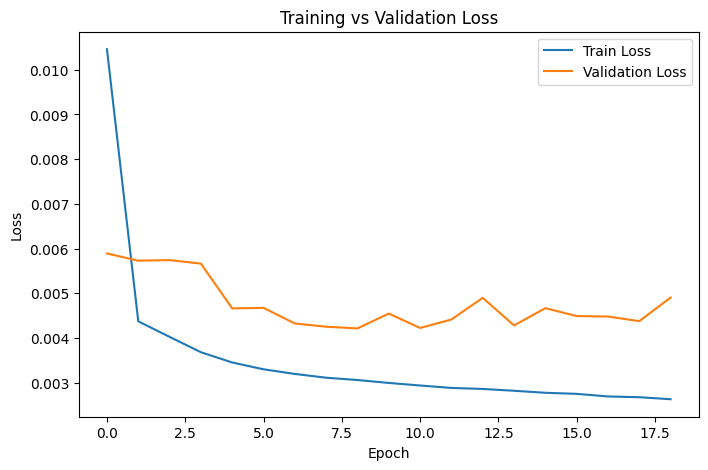

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [67]:
# FIX 3: No .flatten() — model.predict returns (samples, 24). Keep 2D shape.
y_pred_scaled = model.predict(X_test)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [68]:
def inverse_transform_target_only(scaler, y_scaled, feature_columns, target_col):
    """
    Inverse transforms only the target column.
    Works for both 1D (samples,) and 2D (samples, horizon) y_scaled.
    """
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_features = len(feature_columns)

    # Flatten to 1D, inverse transform, then reshape back
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()

    temp = np.zeros((len(y_flat), n_features))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]

    return inv.reshape(original_shape)

In [69]:
# Use train_data.columns, not feature_cols
all_cols = train_data.columns.tolist()

y_test_actual = inverse_transform_target_only(fitted_scaler, y_test,        all_cols, target_col)
y_pred_actual = inverse_transform_target_only(fitted_scaler, y_pred_scaled,  all_cols, target_col)
# Both are shape (samples, 24) — real PM2.5 values
print("y_test_actual shape:", y_test_actual.shape)
print("y_pred_actual shape:", y_pred_actual.shape)

y_test_actual shape: (553, 24)
y_pred_actual shape: (553, 24)


In [70]:
y_pred_actual

array([[136.14565187, 142.4846297 , 145.04042019, ..., 105.32080566,
        113.27701639, 123.46535447],
       [155.38676249, 158.39279573, 158.42639838, ..., 123.61661046,
        132.22858272, 140.37757117],
       [172.14155411, 171.33468767, 168.89608468, ..., 141.7532024 ,
        150.38944814, 155.9822684 ],
       ...,
       [ 45.84254749,  58.73318248,  67.51839282, ...,  56.46382026,
         54.60601494,  62.09116853],
       [ 47.11907987,  57.99977226,  65.94998386, ...,  54.15148215,
         52.50929592,  60.35915282],
       [ 49.1666004 ,  57.85456576,  65.07102721, ...,  52.58439514,
         51.35657652,  59.48159366]])

In [71]:
# FIX 4: Removed duplicate metrics cell. Flatten both arrays for overall metrics.
mae  = mean_absolute_error(y_test_actual.flatten(), y_pred_actual.flatten())
rmse = np.sqrt(mean_squared_error(y_test_actual.flatten(), y_pred_actual.flatten()))
r2   = r2_score(y_test_actual.flatten(), y_pred_actual.flatten())

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 27.1446
RMSE : 34.5935
R²   : 0.1655


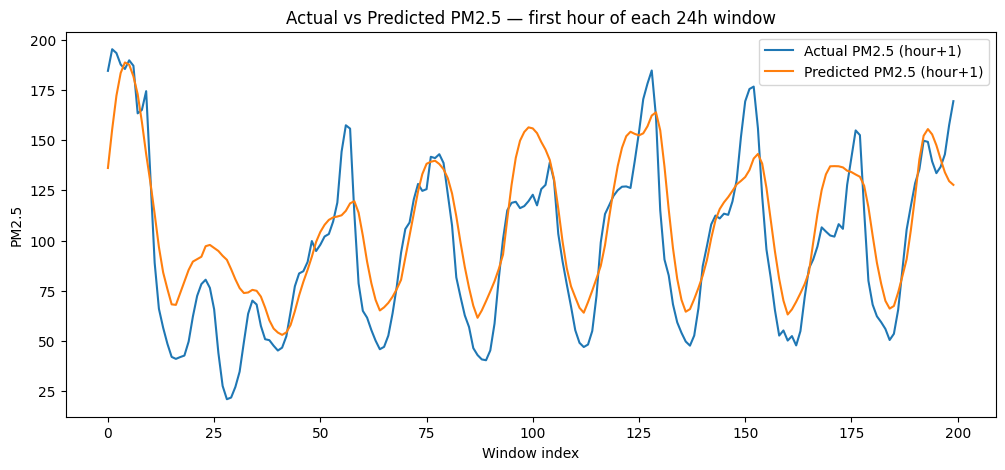

In [72]:
# Plot the first 200 predictions (hour 1 of each 24-hour window)
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:200, 0], label='Actual PM2.5 (hour+1)')
plt.plot(y_pred_actual[:200, 0], label='Predicted PM2.5 (hour+1)')
plt.xlabel('Window index')
plt.ylabel('PM2.5')
plt.title('Actual vs Predicted PM2.5 — first hour of each 24h window')
plt.legend()
plt.show()

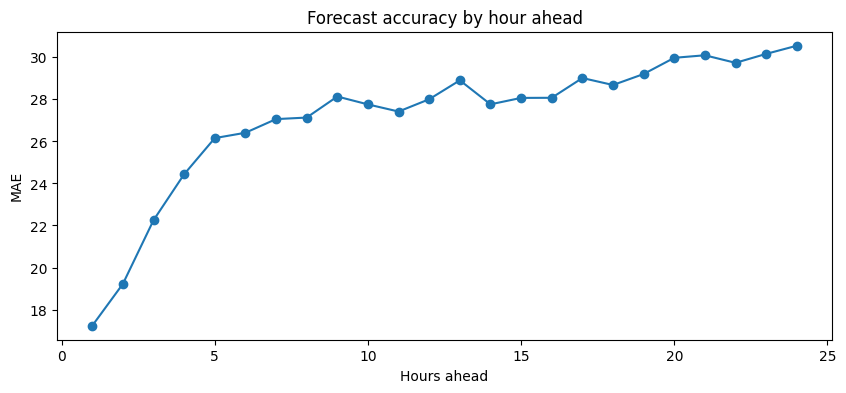

In [73]:
# Per-hour MAE across the 24-hour horizon
per_hour_mae = [mean_absolute_error(y_test_actual[:, h], y_pred_actual[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'R² by hour ahead')

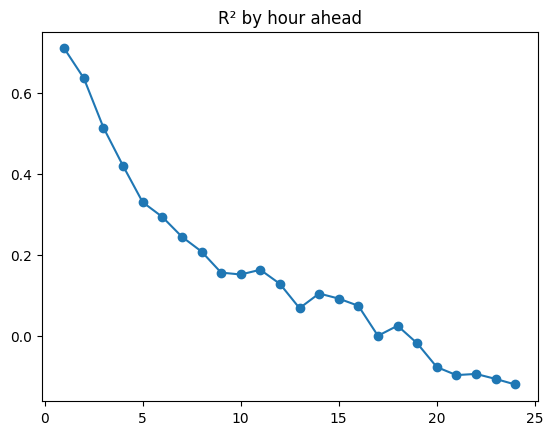

In [74]:
per_hour_r2 = [r2_score(y_test_actual[:, h], y_pred_actual[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2, marker='o')
plt.title('R² by hour ahead')

# Method 2: Predict NO2

In [75]:
no2_target_col   = 'no2'
no2_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [76]:
no2_train_df = train_data[no2_feature_cols].copy()
no2_val_df   = val_data[no2_feature_cols].copy()
no2_test_df  = test_data[no2_feature_cols].copy()

This creates input windows of past observations and predicts the next 24 NO2 values (24-hour horizon).

In [77]:
# horizon=24 so y contains the next 24 hours, matching Dense(24) output.
def create_sequences_no2(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values     = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 11)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [78]:
no2_lookback = 168   # past 7 days
no2_horizon  = 24    # predict next 24 hours

X_train_no2, y_train_no2 = create_sequences_no2(no2_train_df, no2_target_col, no2_lookback, no2_horizon)
X_val_no2,   y_val_no2   = create_sequences_no2(no2_val_df,   no2_target_col, no2_lookback, no2_horizon)
X_test_no2,  y_test_no2  = create_sequences_no2(no2_test_df,  no2_target_col, no2_lookback, no2_horizon)

print('X_train_no2:', X_train_no2.shape)
print('y_train_no2:', y_train_no2.shape)
print('X_val_no2:  ', X_val_no2.shape)
print('X_test_no2: ', X_test_no2.shape)

X_train_no2: (52393, 168, 11)
y_train_no2: (52393, 24)
X_val_no2:   (1225, 168, 11)
X_test_no2:  (553, 168, 11)


In [79]:
from tensorflow.keras.optimizers import Adam

no2_n_features = X_train_no2.shape[2]

model_no2 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(no2_lookback, no2_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(no2_horizon)   # outputs 24 values
])

model_no2.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_no2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop_no2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_no2 = model_no2.fit(
    X_train_no2, y_train_no2,
    validation_data=(X_val_no2, y_val_no2),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_no2],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 0.0149 - mae: 0.0861 - val_loss: 0.0059 - val_mae: 0.0630
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0072 - mae: 0.0630 - val_loss: 0.0053 - val_mae: 0.0596
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0063 - mae: 0.0583 - val_loss: 0.0049 - val_mae: 0.0571
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0057 - mae: 0.0551 - val_loss: 0.0044 - val_mae: 0.0538
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0053 - mae: 0.0529 - val_loss: 0.0041 - val_mae: 0.0520
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0050 - mae: 0.0510 - val_loss: 0.0037 - val_mae: 0.0485
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0047 - mae: 0.0494 - val_loss: 0.0035 - val_mae: 0.0469
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0045 - mae: 0.0483 - val_loss: 0.0032 - val_mae: 0.0450
Epoch 9/50
1638/1638 ━━━

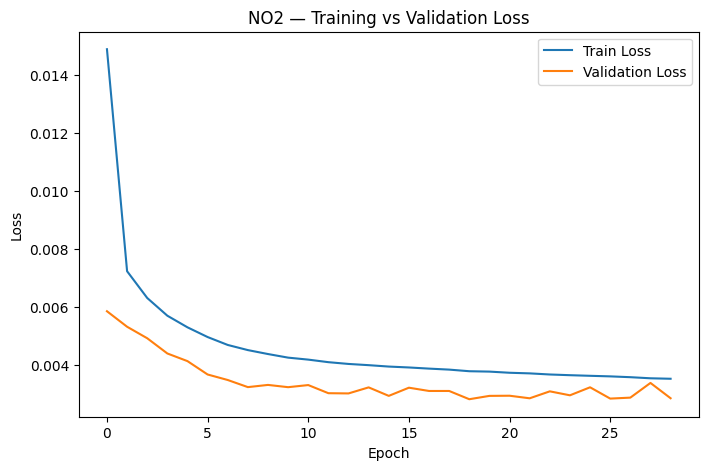

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(history_no2.history['loss'],     label='Train Loss')
plt.plot(history_no2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('NO2 — Training vs Validation Loss')
plt.legend()
plt.show()

In [82]:
# model.predict returns (samples, 24). Keep 2D shape.
y_pred_scaled_no2 = model_no2.predict(X_test_no2)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [83]:
def inverse_transform_target_only_no2(scaler, y_scaled, feature_columns, target_col):
    """
    Inverse transforms only the target column.
    Works for both 1D (samples,) and 2D (samples, horizon) y_scaled.
    """
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_features = len(feature_columns)

    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()

    temp = np.zeros((len(y_flat), n_features))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]

    return inv.reshape(original_shape)

In [84]:
no2_all_cols = train_data.columns.tolist()

y_test_actual_no2 = inverse_transform_target_only_no2(fitted_scaler, y_test_no2,        no2_all_cols, no2_target_col)
y_pred_actual_no2 = inverse_transform_target_only_no2(fitted_scaler, y_pred_scaled_no2, no2_all_cols, no2_target_col)

print('y_test_actual_no2 shape:', y_test_actual_no2.shape)
print('y_pred_actual_no2 shape:', y_pred_actual_no2.shape)

y_test_actual_no2 shape: (553, 24)
y_pred_actual_no2 shape: (553, 24)


In [85]:
mae_no2  = mean_absolute_error(y_test_actual_no2.flatten(), y_pred_actual_no2.flatten())
rmse_no2 = np.sqrt(mean_squared_error(y_test_actual_no2.flatten(), y_pred_actual_no2.flatten()))
r2_no2   = r2_score(y_test_actual_no2.flatten(), y_pred_actual_no2.flatten())

print(f'MAE  : {mae_no2:.4f}')
print(f'RMSE : {rmse_no2:.4f}')
print(f'R²   : {r2_no2:.4f}')

MAE  : 6.6937
RMSE : 8.6268
R²   : 0.4514


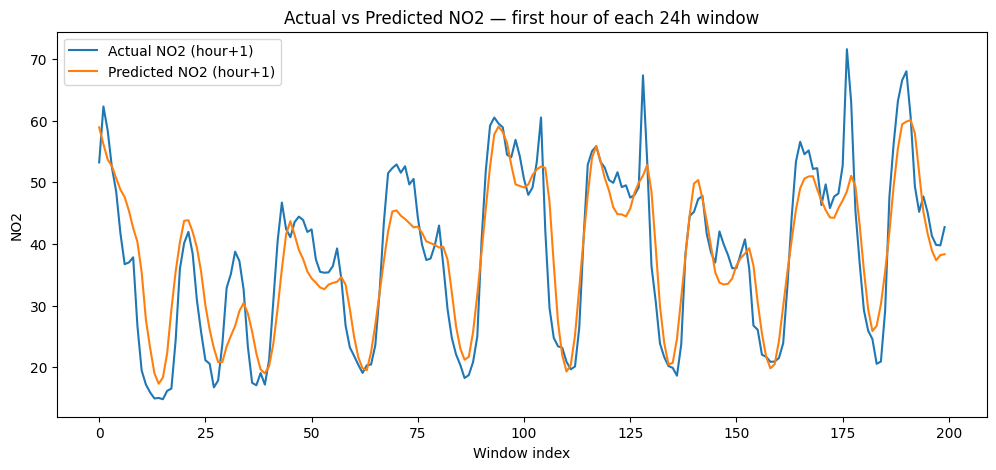

In [86]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual_no2[:200, 0], label='Actual NO2 (hour+1)')
plt.plot(y_pred_actual_no2[:200, 0], label='Predicted NO2 (hour+1)')
plt.xlabel('Window index')
plt.ylabel('NO2')
plt.title('Actual vs Predicted NO2 — first hour of each 24h window')
plt.legend()
plt.show()

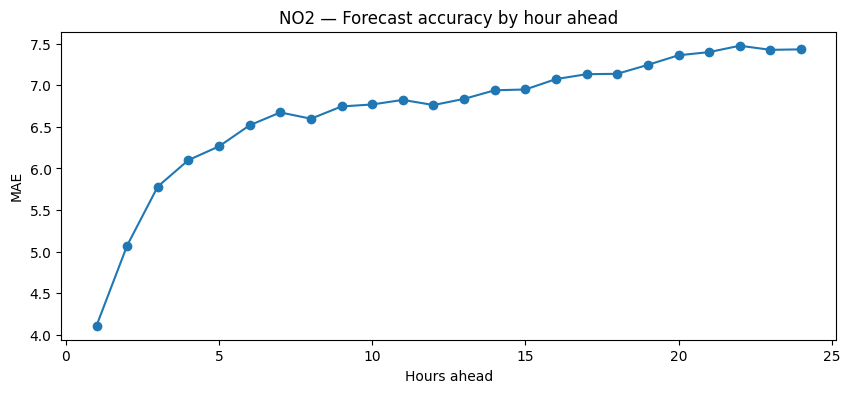

In [87]:
per_hour_mae_no2 = [mean_absolute_error(y_test_actual_no2[:, h], y_pred_actual_no2[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae_no2, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('NO2 — Forecast accuracy by hour ahead')
plt.show()

# Method 3: Predict CO

In [88]:
co_target_col   = 'co'
co_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [89]:
co_train_df = train_data[co_feature_cols].copy()
co_val_df   = val_data[co_feature_cols].copy()
co_test_df  = test_data[co_feature_cols].copy()

This creates input windows of past observations and predicts the next 24 CO values (24-hour horizon).

In [90]:
def create_sequences_co(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values     = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 11)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [91]:
co_lookback = 168   # past 7 days
co_horizon  = 24    # predict next 24 hours

X_train_co, y_train_co = create_sequences_co(co_train_df, co_target_col, co_lookback, co_horizon)
X_val_co,   y_val_co   = create_sequences_co(co_val_df,   co_target_col, co_lookback, co_horizon)
X_test_co,  y_test_co  = create_sequences_co(co_test_df,  co_target_col, co_lookback, co_horizon)

print('X_train_co:', X_train_co.shape)
print('y_train_co:', y_train_co.shape)
print('X_val_co:  ', X_val_co.shape)
print('X_test_co: ', X_test_co.shape)

X_train_co: (52393, 168, 11)
y_train_co: (52393, 24)
X_val_co:   (1225, 168, 11)
X_test_co:  (553, 168, 11)


In [92]:
from tensorflow.keras.optimizers import Adam

co_n_features = X_train_co.shape[2]

model_co = Sequential([
    LSTM(64, return_sequences=True, input_shape=(co_lookback, co_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(co_horizon)   # outputs 24 values
])

model_co.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_co.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
early_stop_co = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_co = model_co.fit(
    X_train_co, y_train_co,
    validation_data=(X_val_co, y_val_co),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_co],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0041 - mae: 0.0429 - val_loss: 0.0021 - val_mae: 0.0359
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0025 - mae: 0.0335 - val_loss: 0.0017 - val_mae: 0.0310
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0021 - mae: 0.0304 - val_loss: 0.0015 - val_mae: 0.0294
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0020 - mae: 0.0293 - val_loss: 0.0015 - val_mae: 0.0301
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0019 - mae: 0.0285 - val_loss: 0.0014 - val_mae: 0.0287
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0018 - mae: 0.0278 - val_loss: 0.0014 - val_mae: 0.0282
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0018 - mae: 0.0274 - val_loss: 0.0013 - val_mae: 0.0269
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0017 - mae: 0.0269 - val_loss: 0.0013 - val_mae: 0.0277
Epoch 9/50
1638/1638 ━━━

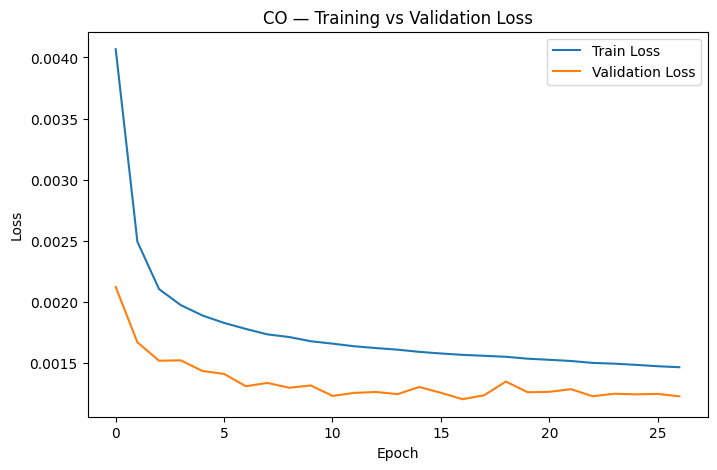

In [94]:
plt.figure(figsize=(8, 5))
plt.plot(history_co.history['loss'],     label='Train Loss')
plt.plot(history_co.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CO — Training vs Validation Loss')
plt.legend()
plt.show()

In [95]:
y_pred_scaled_co = model_co.predict(X_test_co)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [96]:
def inverse_transform_co(scaler, y_scaled, feature_columns, target_col):
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_feat     = len(feature_columns)
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()
    temp = np.zeros((len(y_flat), n_feat))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]
    return inv.reshape(original_shape)

In [97]:
co_all_cols = train_data.columns.tolist()

y_test_actual_co = inverse_transform_co(fitted_scaler, y_test_co,          co_all_cols, co_target_col)
y_pred_actual_co = inverse_transform_co(fitted_scaler, y_pred_scaled_co,   co_all_cols, co_target_col)

print('y_test_actual_co shape:', y_test_actual_co.shape)
print('y_pred_actual_co shape:', y_pred_actual_co.shape)

y_test_actual_co shape: (553, 24)
y_pred_actual_co shape: (553, 24)


In [98]:
mae_co  = mean_absolute_error(y_test_actual_co.flatten(), y_pred_actual_co.flatten())
rmse_co = np.sqrt(mean_squared_error(y_test_actual_co.flatten(), y_pred_actual_co.flatten()))
r2_co   = r2_score(y_test_actual_co.flatten(), y_pred_actual_co.flatten())

print(f'MAE  : {mae_co:.4f}')
print(f'RMSE : {rmse_co:.4f}')
print(f'R²   : {r2_co:.4f}')

MAE  : 0.2543
RMSE : 0.3398
R²   : 0.3063


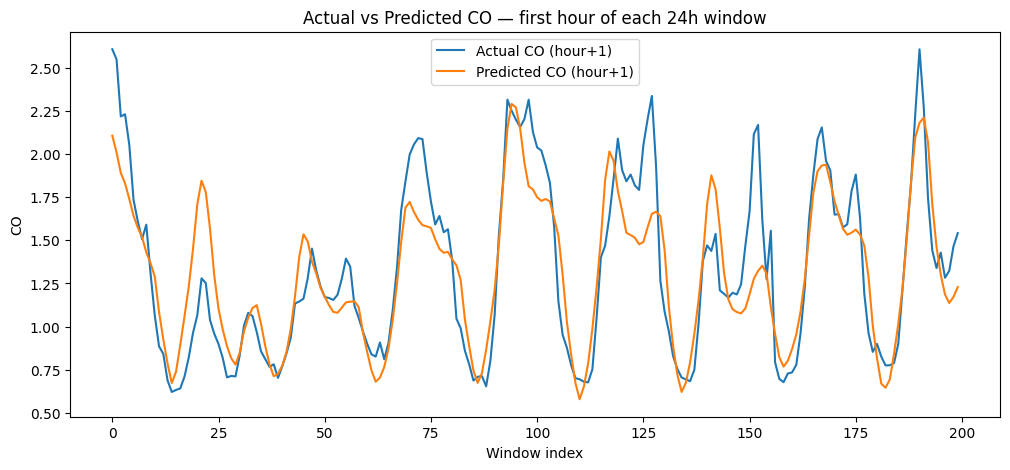

In [99]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual_co[:200, 0], label='Actual CO (hour+1)')
plt.plot(y_pred_actual_co[:200, 0], label='Predicted CO (hour+1)')
plt.xlabel('Window index')
plt.ylabel('CO')
plt.title('Actual vs Predicted CO — first hour of each 24h window')
plt.legend()
plt.show()

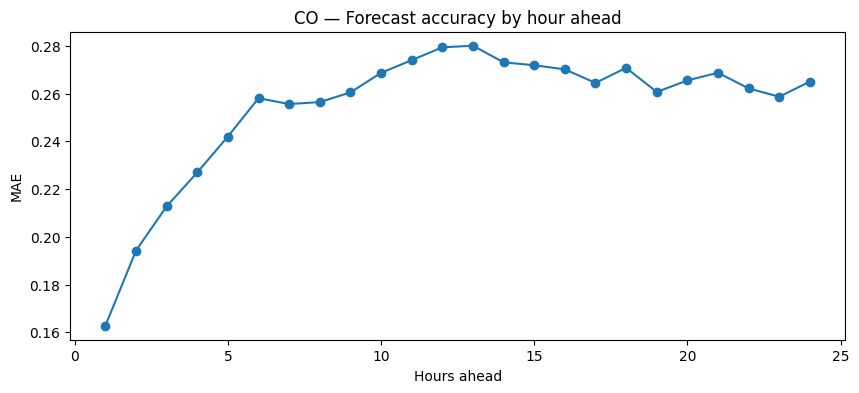

In [100]:
per_hour_mae_co = [mean_absolute_error(y_test_actual_co[:, h], y_pred_actual_co[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae_co, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('CO — Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'CO — R² by hour ahead')

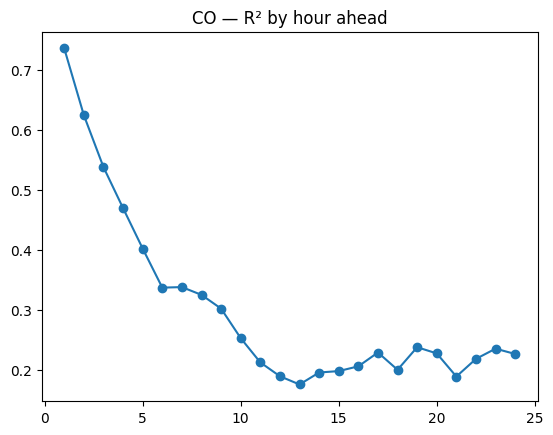

In [101]:
per_hour_r2_co = [r2_score(y_test_actual_co[:, h], y_pred_actual_co[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2_co, marker='o')
plt.title('CO — R² by hour ahead')

# Method 4: Predict Ozone

In [102]:
ozone_target_col   = 'ozone'
ozone_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [103]:
ozone_train_df = train_data[ozone_feature_cols].copy()
ozone_val_df   = val_data[ozone_feature_cols].copy()
ozone_test_df  = test_data[ozone_feature_cols].copy()

This creates input windows of past observations and predicts the next 24 Ozone values (24-hour horizon).

In [104]:
def create_sequences_ozone(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values     = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 11)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [105]:
ozone_lookback = 168   # past 7 days
ozone_horizon  = 24    # predict next 24 hours

X_train_ozone, y_train_ozone = create_sequences_ozone(ozone_train_df, ozone_target_col, ozone_lookback, ozone_horizon)
X_val_ozone,   y_val_ozone   = create_sequences_ozone(ozone_val_df,   ozone_target_col, ozone_lookback, ozone_horizon)
X_test_ozone,  y_test_ozone  = create_sequences_ozone(ozone_test_df,  ozone_target_col, ozone_lookback, ozone_horizon)

print('X_train_ozone:', X_train_ozone.shape)
print('y_train_ozone:', y_train_ozone.shape)
print('X_val_ozone:  ', X_val_ozone.shape)
print('X_test_ozone: ', X_test_ozone.shape)

X_train_ozone: (52393, 168, 11)
y_train_ozone: (52393, 24)
X_val_ozone:   (1225, 168, 11)
X_test_ozone:  (553, 168, 11)


In [106]:
from tensorflow.keras.optimizers import Adam

ozone_n_features = X_train_ozone.shape[2]

model_ozone = Sequential([
    LSTM(64, return_sequences=True, input_shape=(ozone_lookback, ozone_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(ozone_horizon)   # outputs 24 values
])

model_ozone.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_ozone.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
early_stop_ozone = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_ozone = model_ozone.fit(
    X_train_ozone, y_train_ozone,
    validation_data=(X_val_ozone, y_val_ozone),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_ozone],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 0.0240 - mae: 0.1099 - val_loss: 0.0074 - val_mae: 0.0691
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0096 - mae: 0.0732 - val_loss: 0.0050 - val_mae: 0.0557
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0078 - mae: 0.0652 - val_loss: 0.0041 - val_mae: 0.0498
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0070 - mae: 0.0612 - val_loss: 0.0037 - val_mae: 0.0473
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0066 - mae: 0.0591 - val_loss: 0.0035 - val_mae: 0.0458
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0063 - mae: 0.0578 - val_loss: 0.0034 - val_mae: 0.0448
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0061 - mae: 0.0569 - val_loss: 0.0033 - val_mae: 0.0443
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0060 - mae: 0.0563 - val_loss: 0.0032 - val_mae: 0.0440
Epoch 9/50
1638/1638 ━━━

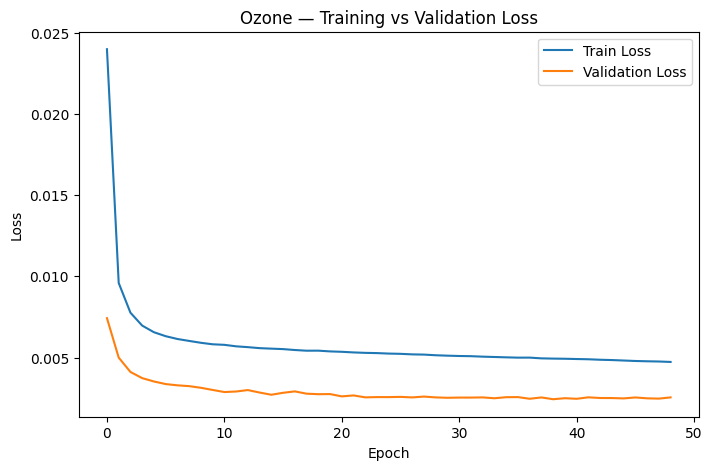

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(history_ozone.history['loss'],     label='Train Loss')
plt.plot(history_ozone.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ozone — Training vs Validation Loss')
plt.legend()
plt.show()

In [109]:
y_pred_scaled_ozone = model_ozone.predict(X_test_ozone)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [110]:
def inverse_transform_ozone(scaler, y_scaled, feature_columns, target_col):
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_feat     = len(feature_columns)
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()
    temp = np.zeros((len(y_flat), n_feat))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]
    return inv.reshape(original_shape)

In [111]:
ozone_all_cols = train_data.columns.tolist()

y_test_actual_ozone = inverse_transform_ozone(fitted_scaler, y_test_ozone,          ozone_all_cols, ozone_target_col)
y_pred_actual_ozone = inverse_transform_ozone(fitted_scaler, y_pred_scaled_ozone,   ozone_all_cols, ozone_target_col)

print('y_test_actual_ozone shape:', y_test_actual_ozone.shape)
print('y_pred_actual_ozone shape:', y_pred_actual_ozone.shape)

y_test_actual_ozone shape: (553, 24)
y_pred_actual_ozone shape: (553, 24)


In [112]:
mae_ozone  = mean_absolute_error(y_test_actual_ozone.flatten(), y_pred_actual_ozone.flatten())
rmse_ozone = np.sqrt(mean_squared_error(y_test_actual_ozone.flatten(), y_pred_actual_ozone.flatten()))
r2_ozone   = r2_score(y_test_actual_ozone.flatten(), y_pred_actual_ozone.flatten())

print(f'MAE  : {mae_ozone:.4f}')
print(f'RMSE : {rmse_ozone:.4f}')
print(f'R²   : {r2_ozone:.4f}')

MAE  : 7.2577
RMSE : 9.5681
R²   : 0.8290


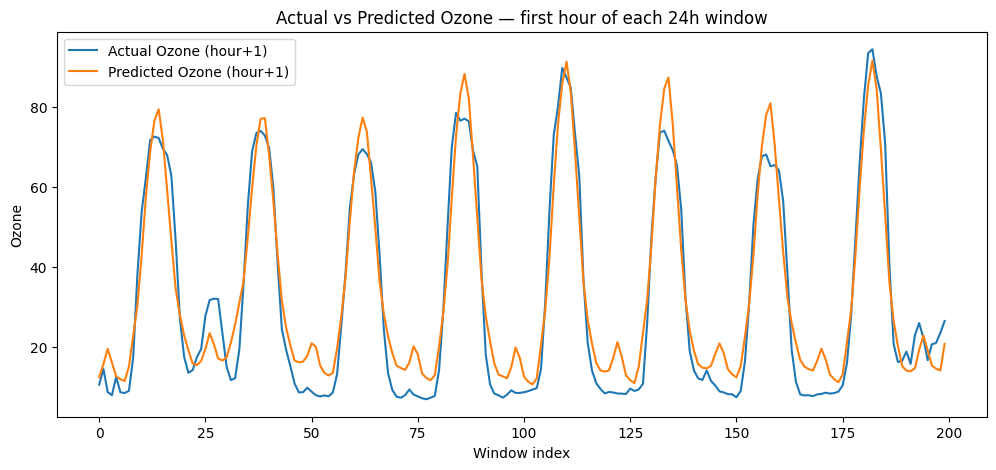

In [113]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual_ozone[:200, 0], label='Actual Ozone (hour+1)')
plt.plot(y_pred_actual_ozone[:200, 0], label='Predicted Ozone (hour+1)')
plt.xlabel('Window index')
plt.ylabel('Ozone')
plt.title('Actual vs Predicted Ozone — first hour of each 24h window')
plt.legend()
plt.show()

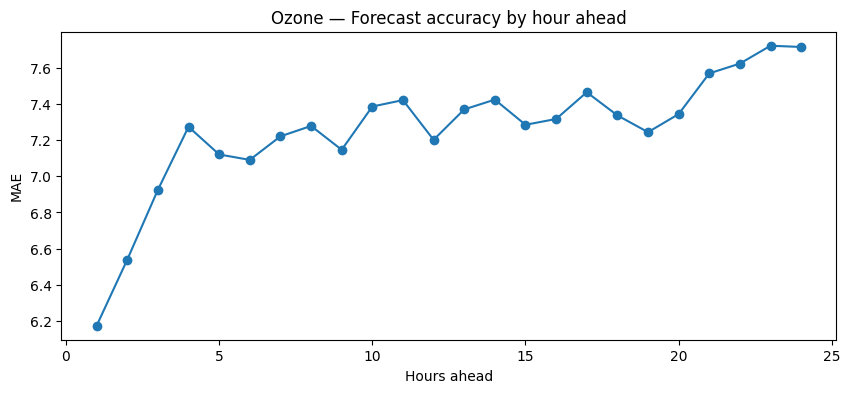

In [114]:
per_hour_mae_ozone = [mean_absolute_error(y_test_actual_ozone[:, h], y_pred_actual_ozone[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae_ozone, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('Ozone — Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'Ozone — R² by hour ahead')

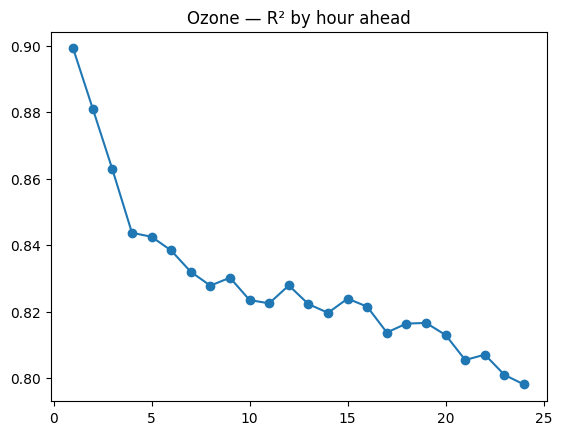

In [115]:
per_hour_r2_ozone = [r2_score(y_test_actual_ozone[:, h], y_pred_actual_ozone[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2_ozone, marker='o')
plt.title('Ozone — R² by hour ahead')

# Method 5: Predict All (Multi-target: PM2.5, NO2, CO, Ozone)

In [116]:
multi_target_cols = ['pm25', 'no2', 'co', 'ozone']
multi_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']


In [117]:
multi_train_df = train_data[multi_feature_cols].copy()
multi_val_df   = val_data[multi_feature_cols].copy()
multi_test_df  = test_data[multi_feature_cols].copy()

Creates sequences where y has shape (samples, 24, 4) — predicting 24 hours ahead for each of the 4 target pollutants simultaneously.

In [118]:
def create_sequences_multi(df, target_cols, lookback=168, horizon=24):
    X, y = [], []
    values      = df.values
    target_idxs = [df.columns.get_loc(c) for c in target_cols]

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])                          # (168, 11)
        y.append(values[i : i + horizon][:, target_idxs])          # (24, 4)

    return np.array(X), np.array(y)

In [119]:
multi_lookback = 168
multi_horizon  = 24

X_train_multi, y_train_multi = create_sequences_multi(multi_train_df, multi_target_cols, multi_lookback, multi_horizon)
X_val_multi,   y_val_multi   = create_sequences_multi(multi_val_df,   multi_target_cols, multi_lookback, multi_horizon)
X_test_multi,  y_test_multi  = create_sequences_multi(multi_test_df,  multi_target_cols, multi_lookback, multi_horizon)

print('X_train_multi:', X_train_multi.shape)  # (samples, 168, 11)
print('y_train_multi:', y_train_multi.shape)  # (samples, 24, 4)
print('X_val_multi:  ', X_val_multi.shape)
print('X_test_multi: ', X_test_multi.shape)

X_train_multi: (52393, 168, 11)
y_train_multi: (52393, 24, 4)
X_val_multi:   (1225, 168, 11)
X_test_multi:  (553, 168, 11)


In [120]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, Lambda, Input
from tensorflow.keras.optimizers import Adam

multi_n_features = X_train_multi.shape[2]
multi_n_targets  = len(multi_target_cols)  # 4

# Use the Functional API so we can slice the last multi_horizon timesteps
# from the LSTM output (168 steps) down to just the forecast window (24 steps).
inputs = Input(shape=(multi_lookback, multi_n_features))
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = Lambda(lambda t: t[:, -multi_horizon:, :])(x)  # slice last 24 steps -> (batch, 24, 32)
x = TimeDistributed(Dense(16, activation='relu'))(x)
outputs = TimeDistributed(Dense(multi_n_targets))(x)  # (batch, 24, 4)

model_multi = Model(inputs, outputs)
model_multi.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_multi.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 168, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 168, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 168, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 4)          │            68 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,468 (126.83 KB)

 Trainable params: 32,468 (126.83 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
early_stop_multi = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_multi = model_multi.fit(
    X_train_multi, y_train_multi,
    validation_data=(X_val_multi, y_val_multi),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_multi],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0087 - mae: 0.0642 - val_loss: 0.0045 - val_mae: 0.0504
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0050 - mae: 0.0487 - val_loss: 0.0040 - val_mae: 0.0476
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0045 - mae: 0.0457 - val_loss: 0.0039 - val_mae: 0.0470
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0043 - mae: 0.0443 - val_loss: 0.0039 - val_mae: 0.0471
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0041 - mae: 0.0434 - val_loss: 0.0037 - val_mae: 0.0456
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0040 - mae: 0.0427 - val_loss: 0.0037 - val_mae: 0.0459
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0039 - mae: 0.0422 - val_loss: 0.0035 - val_mae: 0.0447
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.0039 - mae: 0.0418 - val_loss: 0.0036 - val_mae: 0.0452
Epoch 9/50
1638/1638 ━━━

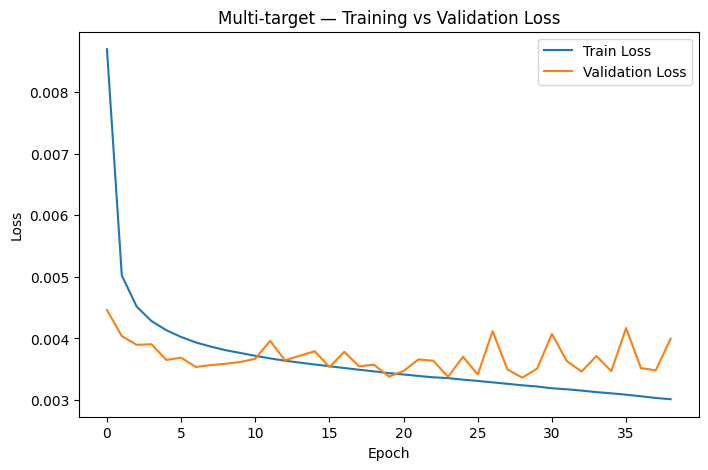

In [122]:
plt.figure(figsize=(8, 5))
plt.plot(history_multi.history['loss'],     label='Train Loss')
plt.plot(history_multi.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Multi-target — Training vs Validation Loss')
plt.legend()
plt.show()

In [123]:
y_pred_scaled_multi = model_multi.predict(X_test_multi)  # shape: (samples, 24, 4)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [124]:
def inverse_transform_multi(scaler, y_scaled, feature_columns, target_cols):
    """
    Inverse transforms multiple target columns.
    y_scaled shape: (samples, horizon, n_targets)
    Returns shape:  (samples, horizon, n_targets)
    """
    y_scaled   = np.array(y_scaled)
    n_feat     = len(feature_columns)
    target_idxs = [list(feature_columns).index(c) for c in target_cols]
    samples, horizon, n_targets = y_scaled.shape

    result = np.zeros_like(y_scaled)
    for t_i, feat_i in enumerate(target_idxs):
        flat = y_scaled[:, :, t_i].flatten()
        temp = np.zeros((len(flat), n_feat))
        temp[:, feat_i] = flat
        inv = scaler.inverse_transform(temp)[:, feat_i]
        result[:, :, t_i] = inv.reshape(samples, horizon)

    return result

In [125]:
multi_all_cols = train_data.columns.tolist()

y_test_actual_multi = inverse_transform_multi(fitted_scaler, y_test_multi,        multi_all_cols, multi_target_cols)
y_pred_actual_multi = inverse_transform_multi(fitted_scaler, y_pred_scaled_multi, multi_all_cols, multi_target_cols)

print('y_test_actual_multi shape:', y_test_actual_multi.shape)  # (samples, 24, 4)
print('y_pred_actual_multi shape:', y_pred_actual_multi.shape)

y_test_actual_multi shape: (553, 24, 4)
y_pred_actual_multi shape: (553, 24, 4)


In [126]:
# Overall metrics across all targets
mae_multi  = mean_absolute_error(y_test_actual_multi.flatten(), y_pred_actual_multi.flatten())
rmse_multi = np.sqrt(mean_squared_error(y_test_actual_multi.flatten(), y_pred_actual_multi.flatten()))
r2_multi   = r2_score(y_test_actual_multi.flatten(), y_pred_actual_multi.flatten())

print(f'Overall MAE  : {mae_multi:.4f}')
print(f'Overall RMSE : {rmse_multi:.4f}')
print(f'Overall R²   : {r2_multi:.4f}')

# Per-target metrics
print()
for i, col in enumerate(multi_target_cols):
    m = mean_absolute_error(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten())
    r = r2_score(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten())
    print(f'{col:>6}  MAE={m:.4f}  R²={r:.4f}')

Overall MAE  : 10.0790
Overall RMSE : 18.3479
Overall R²   : 0.7353

  pm25  MAE=25.4517  R²=0.1928
   no2  MAE=7.3929  R²=0.3306
    co  MAE=0.2578  R²=0.2992
 ozone  MAE=7.2134  R²=0.8167


In [127]:
# Overall metrics across all targets
mae_multi  = mean_absolute_error(y_test_actual_multi.flatten(), y_pred_actual_multi.flatten())
rmse_multi = np.sqrt(mean_squared_error(y_test_actual_multi.flatten(), y_pred_actual_multi.flatten()))
r2_multi   = r2_score(y_test_actual_multi.flatten(), y_pred_actual_multi.flatten())
print(f'Overall MAE  : {mae_multi:.4f}')
print(f'Overall RMSE : {rmse_multi:.4f}')
print(f'Overall R²   : {r2_multi:.4f}')

# Per-target metrics
print()
for i, col in enumerate(multi_target_cols):
    m    = mean_absolute_error(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten())
    rmse = np.sqrt(mean_squared_error(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten()))
    r    = r2_score(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten())
    print(f'{col:>6}  MAE={m:.4f}  RMSE={rmse:.4f}  R²={r:.4f}')

Overall MAE  : 10.0790
Overall RMSE : 18.3479
Overall R²   : 0.7353

  pm25  MAE=25.4517  RMSE=34.0222  R²=0.1928
   no2  MAE=7.3929  RMSE=9.5296  R²=0.3306
    co  MAE=0.2578  RMSE=0.3416  R²=0.2992
 ozone  MAE=7.2134  RMSE=9.9070  R²=0.8167


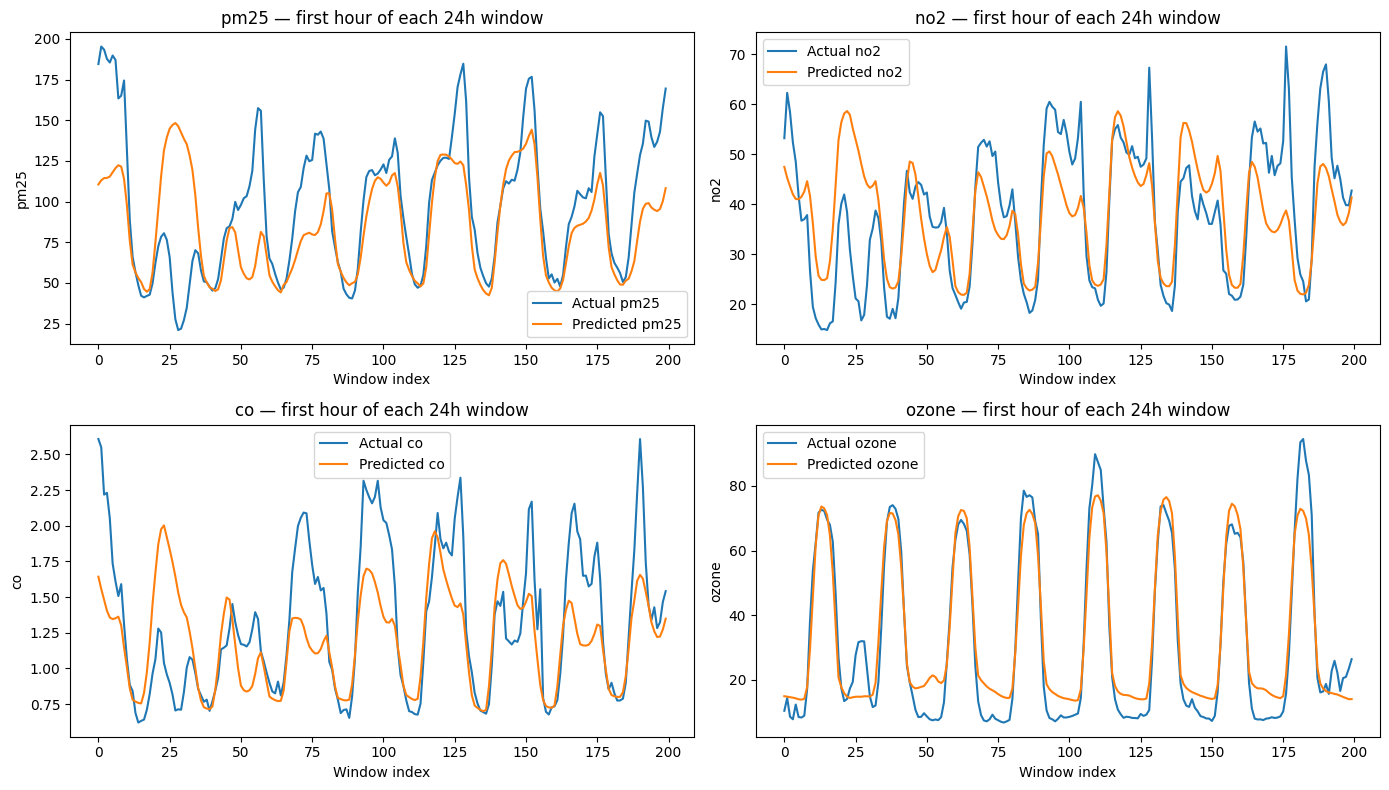

In [128]:
# Plot first hour predictions for each target
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(multi_target_cols):
    axes[i].plot(y_test_actual_multi[:200, 0, i], label=f'Actual {col}')
    axes[i].plot(y_pred_actual_multi[:200, 0, i], label=f'Predicted {col}')
    axes[i].set_title(f'{col} — first hour of each 24h window')
    axes[i].set_xlabel('Window index')
    axes[i].set_ylabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

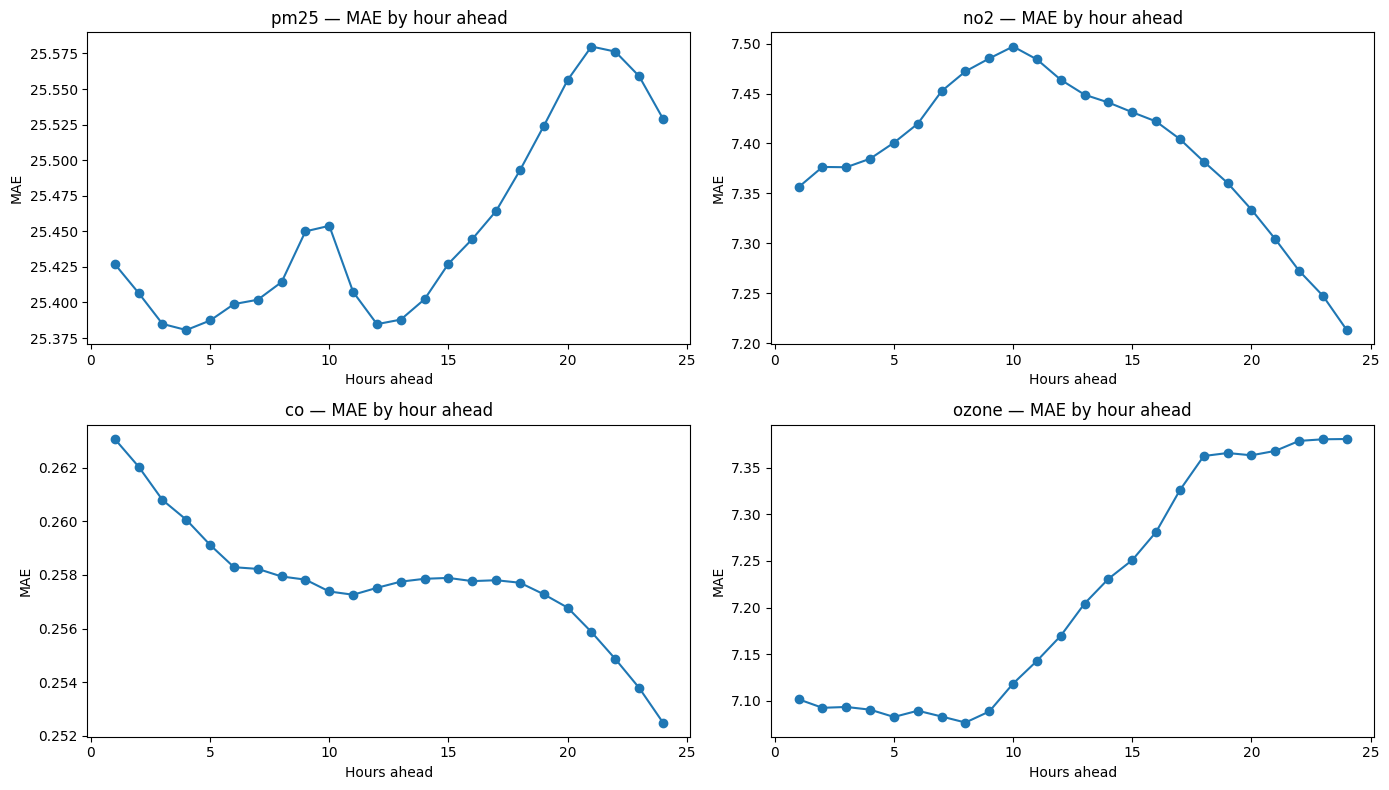

In [129]:
# Per-hour MAE for each target
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(multi_target_cols):
    per_h_mae = [mean_absolute_error(y_test_actual_multi[:, h, i], y_pred_actual_multi[:, h, i]) for h in range(24)]
    axes[i].plot(range(1, 25), per_h_mae, marker='o')
    axes[i].set_title(f'{col} — MAE by hour ahead')
    axes[i].set_xlabel('Hours ahead')
    axes[i].set_ylabel('MAE')

plt.tight_layout()
plt.show()

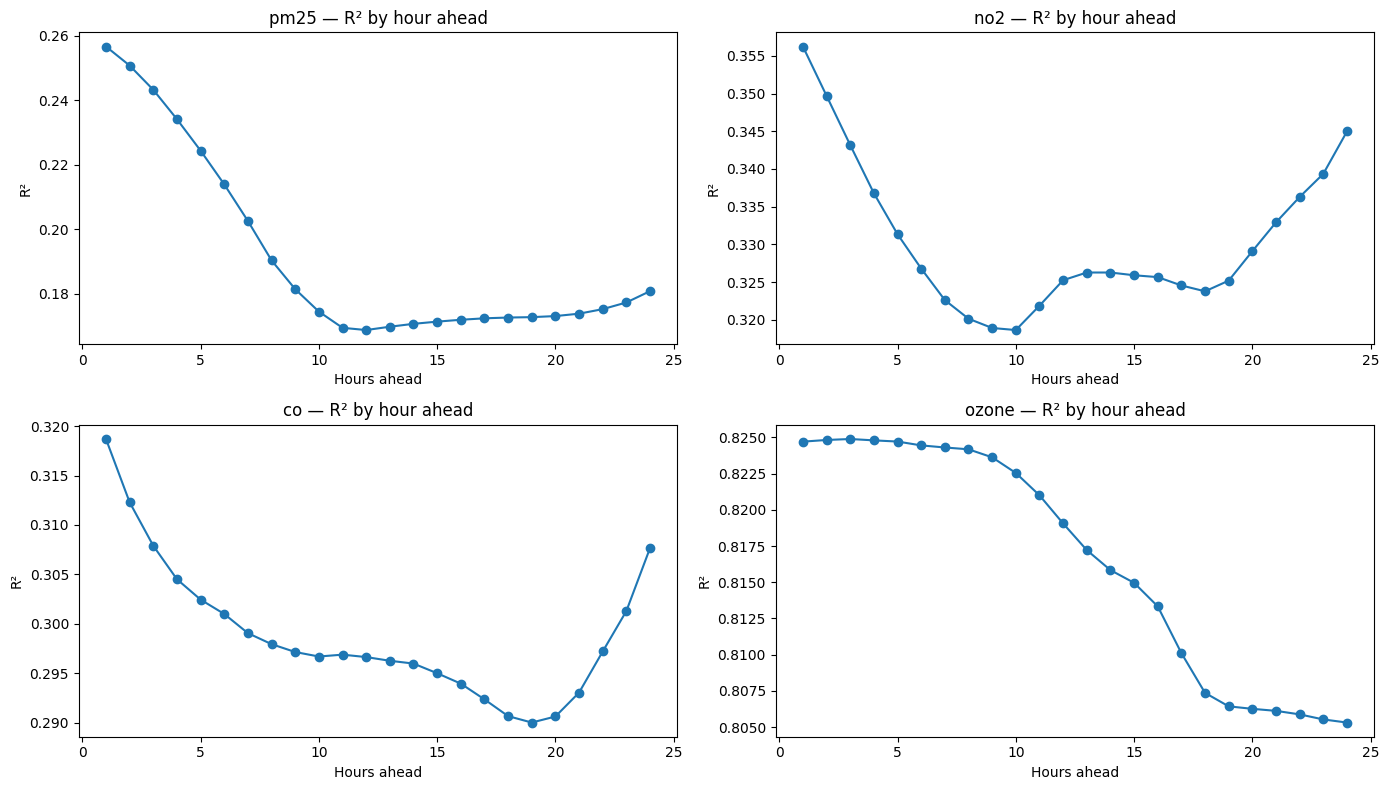

In [130]:
# Per-hour R² for each target
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(multi_target_cols):
    per_h_r2 = [r2_score(y_test_actual_multi[:, h, i], y_pred_actual_multi[:, h, i]) for h in range(24)]
    axes[i].plot(range(1, 25), per_h_r2, marker='o')
    axes[i].set_title(f'{col} — R² by hour ahead')
    axes[i].set_xlabel('Hours ahead')
    axes[i].set_ylabel('R²')

plt.tight_layout()
plt.show()

SAVE MODELS

In [131]:
import os
import joblib

os.makedirs("saved_models", exist_ok=True)

In [132]:
model.save("saved_models/model_all_features.keras")
joblib.dump(fitted_scaler, "saved_models/scaler_all_features.pkl")

['saved_models/scaler_all_features.pkl']

In [133]:
model_no2.save("saved_models/model_no2.keras")
joblib.dump(fitted_scaler, "saved_models/scaler_no2.pkl")

['saved_models/scaler_no2.pkl']

In [134]:
model_co.save("saved_models/model_co.keras")
joblib.dump(fitted_scaler, "saved_models/scaler_co.pkl")

['saved_models/scaler_co.pkl']

In [135]:
model_ozone.save("saved_models/model_ozone.keras")
joblib.dump(fitted_scaler, "saved_models/scaler_ozone.pkl")

['saved_models/scaler_ozone.pkl']

In [136]:
model_multi.save("saved_models/model_multi.keras")
joblib.dump(fitted_scaler, "saved_models/scaler_multi.pkl")

['saved_models/scaler_multi.pkl']

In [137]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, Lambda, Input
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

multi_target_cols  = ['pm25', 'no2', 'co', 'ozone']
multi_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2', 'so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

multi_train_df = train_data[multi_feature_cols].copy()
multi_val_df   = val_data[multi_feature_cols].copy()
multi_test_df  = test_data[multi_feature_cols].copy()

X_train_multi, y_train_multi = create_sequences_multi(multi_train_df, multi_target_cols, 168, 24)
X_val_multi,   y_val_multi   = create_sequences_multi(multi_val_df,   multi_target_cols, 168, 24)
X_test_multi,  y_test_multi  = create_sequences_multi(multi_test_df,  multi_target_cols, 168, 24)

multi_n_features = X_train_multi.shape[2]
multi_n_targets  = len(multi_target_cols)

# --- Task-specific loss weights (PM2.5 weighted higher) ---
# Weights order: [pm25, no2, co, ozone]
task_weights = tf.constant([2.0, 1.0, 1.0, 1.0], dtype=tf.float32)

def weighted_mse(y_true, y_pred):
    # y shape: (batch, 24, 4)
    sq_err = tf.square(y_true - y_pred)           # (batch, 24, 4)
    weighted = sq_err * task_weights               # broadcast over batch & horizon
    return tf.reduce_mean(weighted)

# --- Improved architecture: larger encoder + 3 LSTM layers ---
inputs = Input(shape=(168, multi_n_features))

x = LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=True)(x)
x = Dropout(0.2)(x)

x = Lambda(lambda t: t[:, -24:, :])(x)            # slice last 24 steps

x = TimeDistributed(Dense(32, activation='relu'))(x)
x = TimeDistributed(Dense(16, activation='relu'))(x)
outputs = TimeDistributed(Dense(multi_n_targets))(x)  # (batch, 24, 4)

model_multi_v2 = Model(inputs, outputs)
model_multi_v2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=weighted_mse,
    metrics=['mae']
)
model_multi_v2.summary()

# --- Train with more epochs ---
early_stop_multi_v2 = EarlyStopping(
    monitor='val_loss',
    patience=15,               # more patience
    restore_best_weights=True
)

history_multi_v2 = model_multi_v2.fit(
    X_train_multi, y_train_multi,
    validation_data=(X_val_multi, y_val_multi),
    epochs=100,                # increased from 50
    batch_size=32,
    callbacks=[early_stop_multi_v2],
    verbose=1
)

# --- Evaluate ---
y_pred_scaled_multi_v2 = model_multi_v2.predict(X_test_multi)

y_test_actual_multi_v2 = inverse_transform_multi(fitted_scaler, y_test_multi,           multi_all_cols, multi_target_cols)
y_pred_actual_multi_v2 = inverse_transform_multi(fitted_scaler, y_pred_scaled_multi_v2, multi_all_cols, multi_target_cols)

print()
for i, col in enumerate(multi_target_cols):
    m    = mean_absolute_error(y_test_actual_multi_v2[:, :, i].flatten(), y_pred_actual_multi_v2[:, :, i].flatten())
    rmse = np.sqrt(mean_squared_error(y_test_actual_multi_v2[:, :, i].flatten(), y_pred_actual_multi_v2[:, :, i].flatten()))
    r    = r2_score(y_test_actual_multi_v2[:, :, i].flatten(), y_pred_actual_multi_v2[:, :, i].flatten())
    print(f'{col:>6}  MAE={m:.4f}  RMSE={rmse:.4f}  R²={r:.4f}')

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 168, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 168, 128)       │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 168, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 168, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 168, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 24, 32)         │         1,056 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 24, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 24, 4)          │            68 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,156 (527.95 KB)

 Trainable params: 135,156 (527.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - loss: 0.0124 - mae: 0.0730 - val_loss: 0.0062 - val_mae: 0.0515
Epoch 2/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0062 - mae: 0.0490 - val_loss: 0.0060 - val_mae: 0.0489
Epoch 3/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0056 - mae: 0.0462 - val_loss: 0.0057 - val_mae: 0.0479
Epoch 4/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0053 - mae: 0.0447 - val_loss: 0.0060 - val_mae: 0.0489
Epoch 5/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0050 - mae: 0.0437 - val_loss: 0.0060 - val_mae: 0.0484
Epoch 6/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0049 - mae: 0.0430 - val_loss: 0.0064 - val_mae: 0.0485
Epoch 7/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0047 - mae: 0.0424 - val_loss: 0.0065 - val_mae: 0.0489
Epoch 8/100
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0046 - mae: 0.0418 - val_loss: 0.0074 - val_mae: 0.0507
Epoch 9/100
1638

In [138]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ── 1. Define targets and features ──────────────────────────────────────────
multi_target_cols  = ['pm25', 'no2', 'co', 'ozone']
multi_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2', 'so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

multi_train_df = train_data[multi_feature_cols].copy()
multi_val_df   = val_data[multi_feature_cols].copy()
multi_test_df  = test_data[multi_feature_cols].copy()

multi_n_features = len(multi_feature_cols)
multi_lookback   = 168
multi_horizon    = 24
multi_n_targets  = len(multi_target_cols)  # 4

# ── 2. Sequence creation — y flattened to (samples, 24*4=96) ────────────────
def create_sequences_multi(df, target_cols, lookback=168, horizon=24):
    X, y = [], []
    values      = df.values
    target_idxs = [df.columns.get_loc(c) for c in target_cols]

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])                           # (168, 11)
        y.append(values[i : i + horizon][:, target_idxs].flatten())  # (96,)

    return np.array(X), np.array(y)

X_train_multi, y_train_multi = create_sequences_multi(multi_train_df, multi_target_cols, multi_lookback, multi_horizon)
X_val_multi,   y_val_multi   = create_sequences_multi(multi_val_df,   multi_target_cols, multi_lookback, multi_horizon)
X_test_multi,  y_test_multi  = create_sequences_multi(multi_test_df,  multi_target_cols, multi_lookback, multi_horizon)

print('X_train_multi:', X_train_multi.shape)  # (samples, 168, 11)
print('y_train_multi:', y_train_multi.shape)  # (samples, 96)

# ── 3. Model — identical to STL, only output size differs ───────────────────
model_multi = Sequential([
    LSTM(64, return_sequences=True, input_shape=(multi_lookback, multi_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(multi_horizon * multi_n_targets)  # 24 * 4 = 96
])

model_multi.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])
model_multi.summary()

# ── 4. Train ─────────────────────────────────────────────────────────────────
early_stop_multi = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_multi = model_multi.fit(
    X_train_multi, y_train_multi,
    validation_data=(X_val_multi, y_val_multi),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_multi],
    verbose=1
)

# ── 5. Predict and reshape to (samples, 24, 4) ───────────────────────────────
y_pred_scaled_multi = model_multi.predict(X_test_multi).reshape(-1, multi_horizon, multi_n_targets)
y_test_multi_3d     = y_test_multi.reshape(-1, multi_horizon, multi_n_targets)

# ── 6. Inverse transform ─────────────────────────────────────────────────────
def inverse_transform_multi(scaler, y_scaled, feature_columns, target_cols):
    y_scaled    = np.array(y_scaled)
    n_feat      = len(feature_columns)
    target_idxs = [list(feature_columns).index(c) for c in target_cols]
    samples, horizon, n_targets = y_scaled.shape
    result = np.zeros_like(y_scaled)
    for t_i, feat_i in enumerate(target_idxs):
        flat = y_scaled[:, :, t_i].flatten()
        temp = np.zeros((len(flat), n_feat))
        temp[:, feat_i] = flat
        inv = scaler.inverse_transform(temp)[:, feat_i]
        result[:, :, t_i] = inv.reshape(samples, horizon)
    return result

multi_all_cols = train_data.columns.tolist()

y_test_actual_multi = inverse_transform_multi(fitted_scaler, y_test_multi_3d,        multi_all_cols, multi_target_cols)
y_pred_actual_multi = inverse_transform_multi(fitted_scaler, y_pred_scaled_multi,    multi_all_cols, multi_target_cols)

# ── 7. Metrics ───────────────────────────────────────────────────────────────
print()
for i, col in enumerate(multi_target_cols):
    m    = mean_absolute_error(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten())
    rmse = np.sqrt(mean_squared_error(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten()))
    r    = r2_score(y_test_actual_multi[:, :, i].flatten(), y_pred_actual_multi[:, :, i].flatten())
    print(f'{col:>6}  MAE={m:.4f}  RMSE={rmse:.4f}  R²={r:.4f}')

X_train_multi: (52393, 168, 11)
y_train_multi: (52393, 96)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 96)             │         1,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,032 (132.94 KB)

 Trainable params: 34,032 (132.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0144 - mae: 0.0822 - val_loss: 0.0069 - val_mae: 0.0639
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0069 - mae: 0.0584 - val_loss: 0.0050 - val_mae: 0.0542
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0057 - mae: 0.0529 - val_loss: 0.0048 - val_mae: 0.0535
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0054 - mae: 0.0511 - val_loss: 0.0043 - val_mae: 0.0506
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0049 - mae: 0.0489 - val_loss: 0.0039 - val_mae: 0.0475
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0046 - mae: 0.0469 - val_loss: 0.0036 - val_mae: 0.0458
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0044 - mae: 0.0457 - val_loss: 0.0035 - val_mae: 0.0446
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0043 - mae: 0.0450 - val_loss: 0.0034 - val_mae: 0.0441
Epoch 9/50
1638/1638 ━━━

MULTI-TASK

Using device: cuda
Building sequences...
X_train_mtl : (52393, 168, 11)
y_train_mtl : (52393, 24, 4)
Epoch   1/50  Train: -0.2917  Val: -0.6372  [pm25: 0.0062 | no2: 0.0061 | co: 0.0015 | ozone: 0.0036]
Epoch   5/50  Train: -2.9158  Val: -3.2462  [pm25: 0.0056 | no2: 0.0039 | co: 0.0015 | ozone: 0.0030]
Epoch  10/50  Train: -6.1504  Val: -6.4748  [pm25: 0.0058 | no2: 0.0042 | co: 0.0015 | ozone: 0.0032]
Epoch  15/50  Train: -9.3345  Val: -9.6547  [pm25: 0.0057 | no2: 0.0038 | co: 0.0015 | ozone: 0.0030]
Epoch  20/50  Train: -12.4108  Val: -12.6992  [pm25: 0.0059 | no2: 0.0040 | co: 0.0015 | ozone: 0.0029]
Epoch  25/50  Train: -15.2504  Val: -15.4691  [pm25: 0.0058 | no2: 0.0039 | co: 0.0015 | ozone: 0.0029]
Epoch  30/50  Train: -17.5776  Val: -17.6794  [pm25: 0.0056 | no2: 0.0037 | co: 0.0015 | ozone: 0.0029]
Epoch  35/50  Train: -18.9515  Val: -18.5847  [pm25: 0.0058 | no2: 0.0036 | co: 0.0016 | ozone: 0.0029]
Epoch  40/50  Train: -19.4241  Val: -18.6856  [pm25: 0.0055 | no2: 0.0035 |

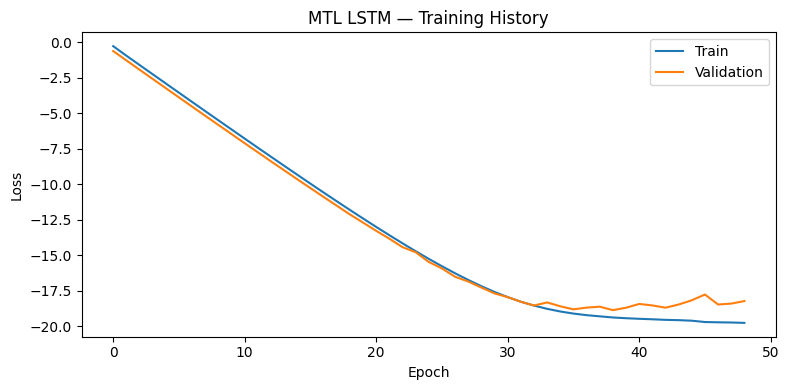


── Overall metrics ──
MAE : 9.9653
RMSE: 17.9900
R²  : 0.7455

── Per-task metrics ──
  pm25      MAE=25.0138  RMSE=33.3188  R²=0.2258
  no2       MAE=7.0379  RMSE=9.0737  R²=0.3931
  co        MAE=0.2542  RMSE=0.3397  R²=0.3069
  ozone     MAE=7.5553  RMSE=10.0976  R²=0.8095

── Learned task weights (lower log_var = task trusted more) ──
  pm25      log_var=-6.0854  σ²=0.0023
  no2       log_var=-5.7002  σ²=0.0033
  co        log_var=-6.5195  σ²=0.0015
  ozone     log_var=-5.3558  σ²=0.0047


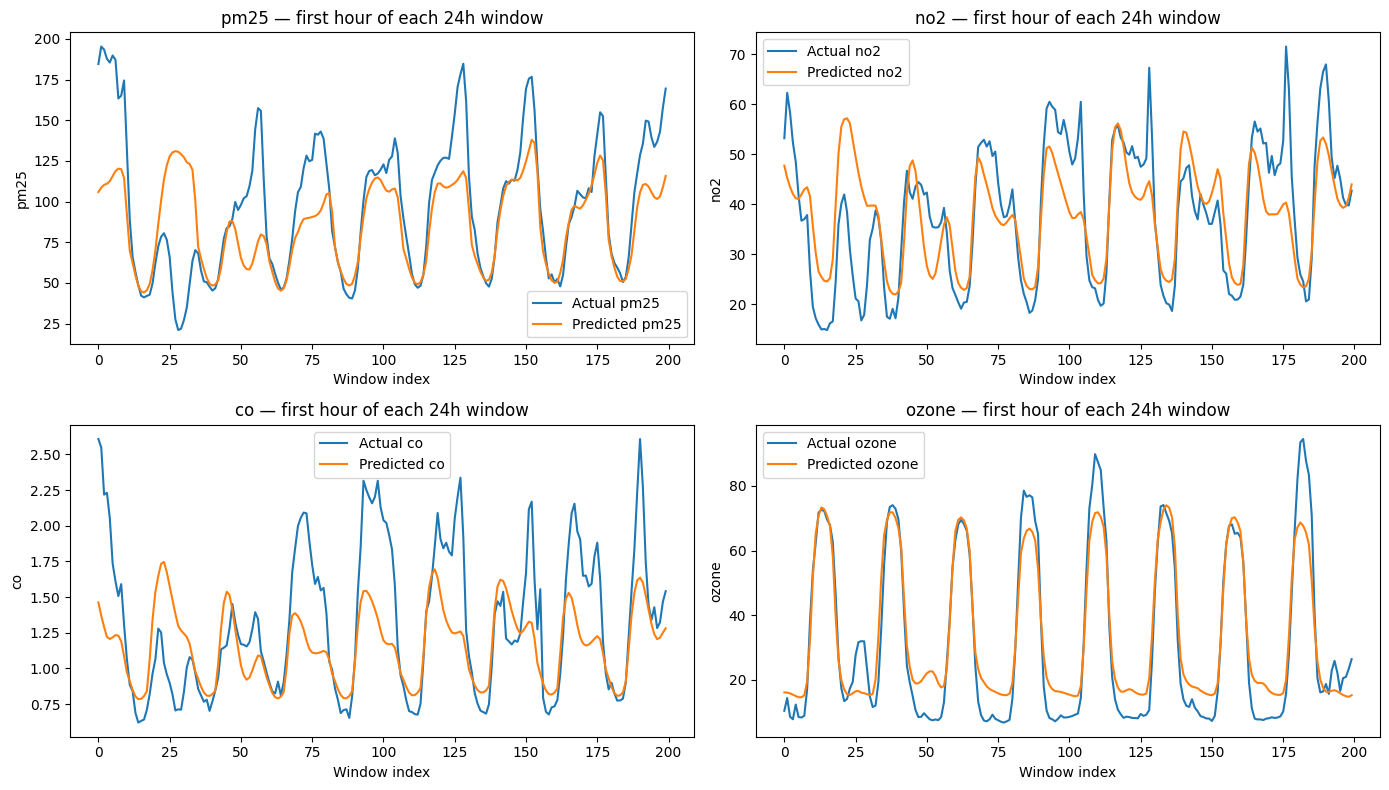

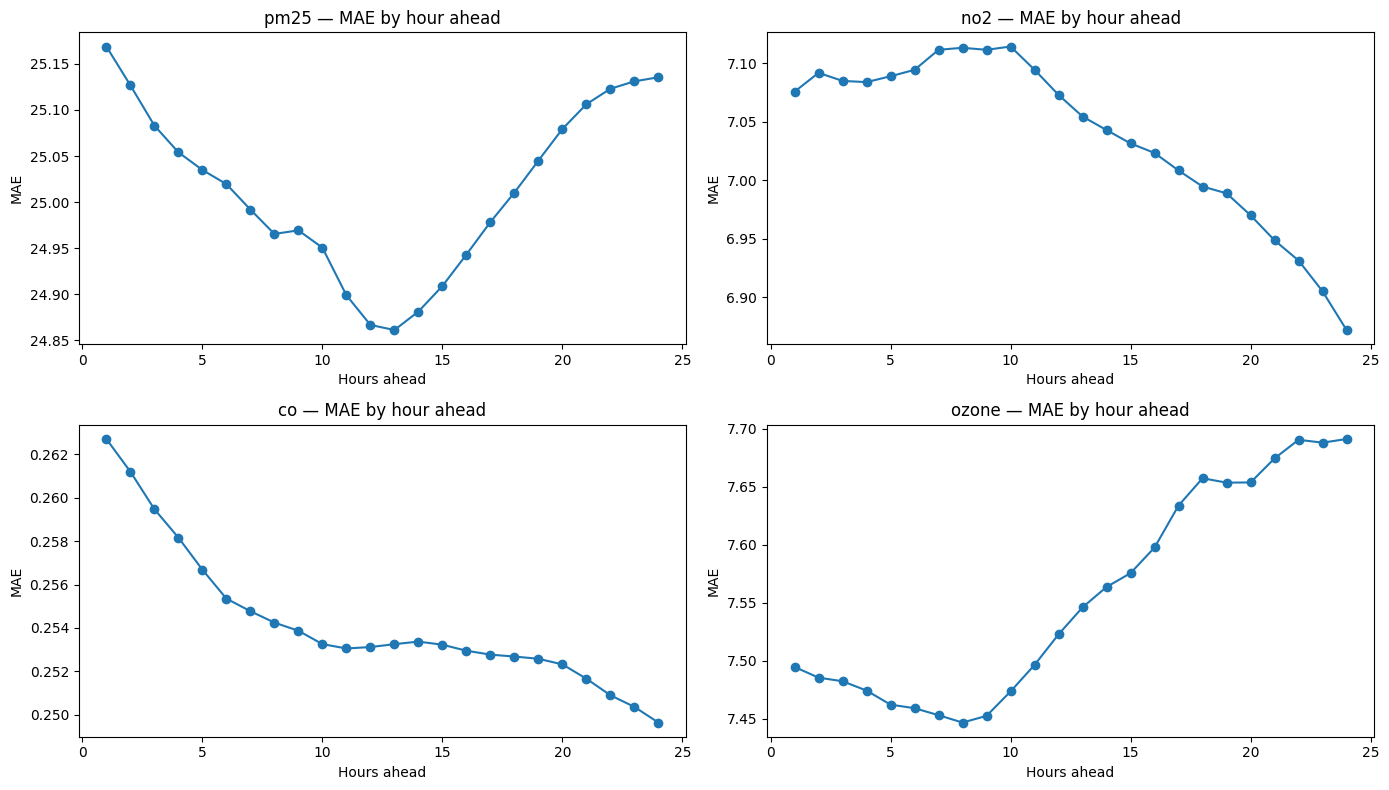

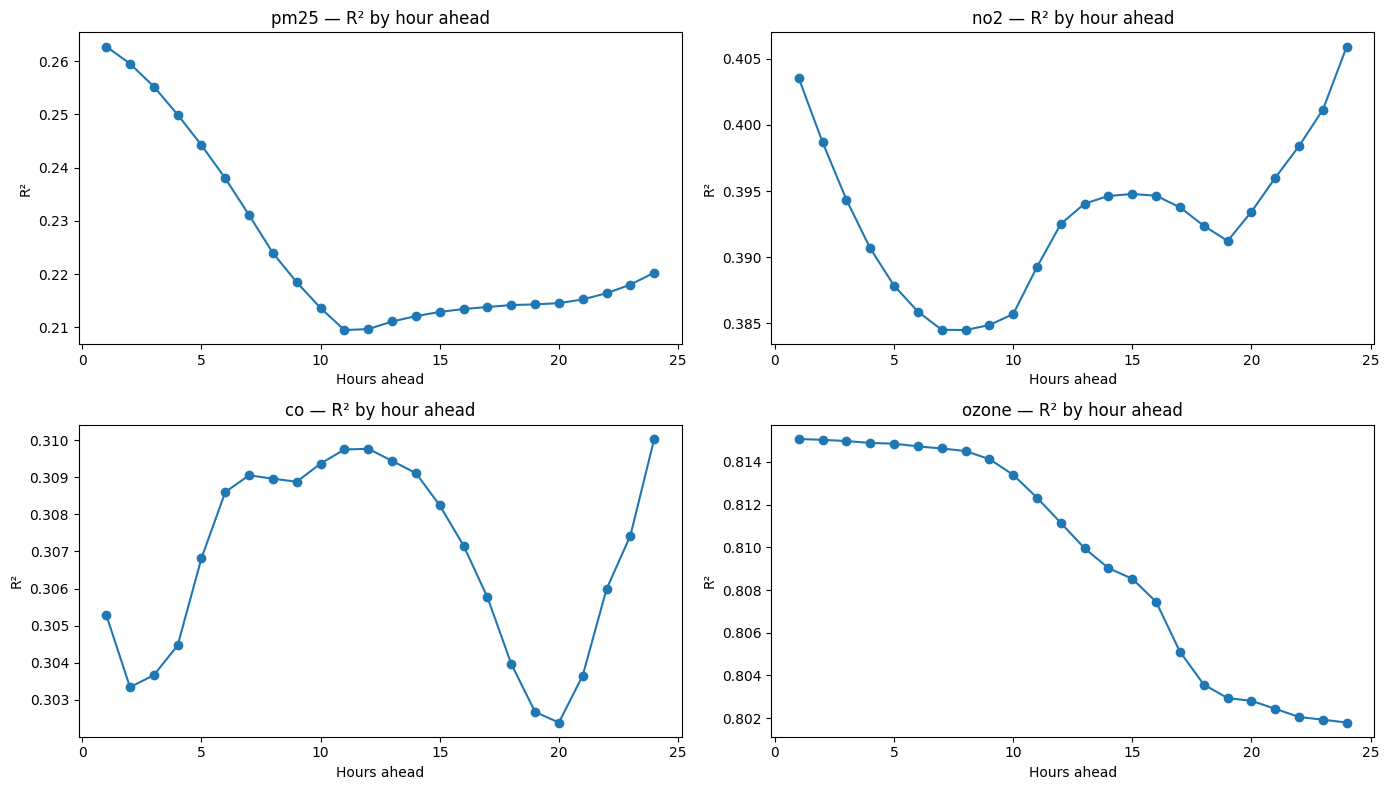


Model saved → saved_models/model_mtl_pytorch.pt


In [139]:
"""
Method 6 — Multi-Task LSTM (PyTorch)
=====================================
Shared LSTM encoder → 4 independent heads, one per pollutant.
Each head predicts the full 24-hour horizon (matching Methods 1–5).

Drop this file into the same notebook environment after running Cell 3
(which gives you train_data, val_data, test_data, fitted_scaler).
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# 0.  CONFIG  (mirrors your existing notebook settings)
# ─────────────────────────────────────────────────────────────────
LOOKBACK      = 168          # past 15 days
HORIZON       = 24           # predict next 24 hours
BATCH_SIZE    = 32
EPOCHS        = 50
LR            = 1e-4         # same as your Keras Adam lr
PATIENCE      = 10           # early-stopping patience
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

FEATURE_COLS  = ['pm25', 'pm10', 'no', 'nh3', 'no2', 'so2',
                 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']
TARGET_COLS   = ['pm25', 'no2', 'co', 'ozone']

print(f"Using device: {DEVICE}")


# ─────────────────────────────────────────────────────────────────
# 1.  SEQUENCE BUILDER  (identical logic to your create_sequences_multi)
# ─────────────────────────────────────────────────────────────────
def create_sequences_multi(df, feature_cols, target_cols,
                           lookback=LOOKBACK, horizon=HORIZON):
    """
    Returns
    -------
    X : np.ndarray  (samples, lookback, n_features)
    y : np.ndarray  (samples, horizon, n_targets)
    """
    values      = df[feature_cols].values
    target_idxs = [feature_cols.index(c) for c in target_cols]
    X, y = [], []
    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])                       # (168, 11)
        y.append(values[i : i + horizon][:, target_idxs])       # (24, 4)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# ─────────────────────────────────────────────────────────────────
# 2.  DATASET
# ─────────────────────────────────────────────────────────────────
class MultiTargetDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)   # (samples, 168, 11)
        self.y = torch.from_numpy(y)   # (samples, 24,  4)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ─────────────────────────────────────────────────────────────────
# 3.  MODEL
# ─────────────────────────────────────────────────────────────────
class MultiTaskLSTM(nn.Module):
    """
    Architecture
    ────────────
    Input (batch, 168, 11)
        │
    LSTM(64, return_sequences) → Dropout
        │
    LSTM(32, return_sequences) → Dropout
        │
    Slice last 24 timesteps  → (batch, 24, 32)
        │
    ┌───┴───┬───────┬────────┐
    Head    Head    Head    Head
    pm25    no2     co    ozone
    Dense(16)→Dense(1) each
        │       │       │      │
    (b,24,1)(b,24,1)(b,24,1)(b,24,1)
        └───┬───┘
    stack → (batch, 24, 4)
    """
    def __init__(
        self,
        input_size : int,
        hidden1    : int   = 64,
        hidden2    : int   = 32,
        horizon    : int   = HORIZON,
        n_targets  : int   = 4,
        dropout    : float = 0.2,
    ):
        super().__init__()
        self.horizon   = horizon
        self.n_targets = n_targets

        # ── Shared encoder ──────────────────────────────────
        self.lstm1   = nn.LSTM(input_size, hidden1, batch_first=True)
        self.drop1   = nn.Dropout(dropout)
        self.lstm2   = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2   = nn.Dropout(dropout)

        # ── Per-task heads (each sees one timestep at a time via TimeDistributed) ──
        # We apply them over the 24-step slice with a simple loop in forward()
        def _head():
            return nn.Sequential(
                nn.Linear(hidden2, 16),
                nn.ReLU(),
                nn.Linear(16, 1),          # → scalar per timestep
            )

        self.heads = nn.ModuleList([_head() for _ in range(n_targets)])

    def forward(self, x):
        # x: (batch, 168, input_size)
        out, _ = self.lstm1(x)                       # (batch, 168, hidden1)
        out     = self.drop1(out)
        out, _ = self.lstm2(out)                     # (batch, 168, hidden2)
        out     = self.drop2(out)

        # Slice last `horizon` timesteps — mirrors your Keras Lambda layer
        out = out[:, -self.horizon:, :]              # (batch, 24, hidden2)

        # Apply each head over all 24 timesteps → (batch, 24, 1) per head
        task_preds = [head(out) for head in self.heads]   # 4 × (batch, 24, 1)

        # Stack → (batch, 24, 4)
        return torch.cat(task_preds, dim=-1)


# ─────────────────────────────────────────────────────────────────
# 4.  WEIGHTED MULTI-TASK LOSS  (Kendall et al., 2018)
#     L = Σ  (1/2σ²) * MSE_task  +  log σ
#     log_vars (= log σ²) are learnable — model finds optimal weights
# ─────────────────────────────────────────────────────────────────
class WeightedMTLoss(nn.Module):
    def __init__(self, n_tasks: int = 4):
        super().__init__()
        self.log_vars = nn.Parameter(torch.zeros(n_tasks))   # log σ²

    def forward(self, preds, targets):
        # preds, targets: (batch, 24, 4)
        task_losses = torch.stack([
            nn.functional.mse_loss(preds[..., i], targets[..., i])
            for i in range(preds.shape[-1])
        ])                                         # (4,)
        precision = torch.exp(-self.log_vars)      # 1/σ²
        weighted  = precision * task_losses + self.log_vars
        return weighted.sum(), task_losses.detach()


# ─────────────────────────────────────────────────────────────────
# 5.  INVERSE TRANSFORM  (matches your existing helper)
# ─────────────────────────────────────────────────────────────────
def inverse_transform_multi(scaler, y_scaled, all_feature_cols, target_cols):
    """
    y_scaled : (samples, horizon, n_targets)  — numpy
    Returns  : (samples, horizon, n_targets)  — original scale
    """
    y_scaled    = np.array(y_scaled)
    n_feat      = len(all_feature_cols)
    target_idxs = [list(all_feature_cols).index(c) for c in target_cols]
    samples, horizon, n_targets = y_scaled.shape
    result = np.zeros_like(y_scaled)

    for t_i, feat_i in enumerate(target_idxs):
        flat      = y_scaled[:, :, t_i].flatten()
        temp      = np.zeros((len(flat), n_feat))
        temp[:, feat_i] = flat
        inv       = scaler.inverse_transform(temp)[:, feat_i]
        result[:, :, t_i] = inv.reshape(samples, horizon)

    return result


# ─────────────────────────────────────────────────────────────────
# 6.  TRAINER
# ─────────────────────────────────────────────────────────────────
class Trainer:
    def __init__(self, model, criterion, optimizer, device, scheduler=None):
        self.model     = model.to(device)
        self.criterion = criterion.to(device)
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device    = device
        self.history   = {"train_loss": [], "val_loss": []}

    def _run_epoch(self, loader, train: bool):
        self.model.train(train)
        total_loss  = 0.0
        task_losses = torch.zeros(len(TARGET_COLS))

        with torch.set_grad_enabled(train):
            for x_batch, y_batch in loader:
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                preds            = self.model(x_batch)
                loss, t_losses   = self.criterion(preds, y_batch)

                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()

                total_loss  += loss.item()
                task_losses += t_losses.cpu()

        n = len(loader)
        return total_loss / n, task_losses / n

    def fit(self, train_loader, val_loader, epochs=EPOCHS):
        best_val  = float("inf")
        wait      = 0
        best_state = None

        for epoch in range(1, epochs + 1):
            tr_loss, _        = self._run_epoch(train_loader, train=True)
            vl_loss, vl_task  = self._run_epoch(val_loader,   train=False)

            if self.scheduler:
                self.scheduler.step(vl_loss)

            self.history["train_loss"].append(tr_loss)
            self.history["val_loss"].append(vl_loss)

            # ── Early stopping ──────────────────────────────
            if vl_loss < best_val:
                best_val   = vl_loss
                wait       = 0
                best_state = {k: v.cpu().clone()
                              for k, v in self.model.state_dict().items()}
            else:
                wait += 1
                if wait >= PATIENCE:
                    print(f"\nEarly stopping at epoch {epoch}")
                    break

            if epoch % 5 == 0 or epoch == 1:
                task_str = " | ".join(
                    f"{n}: {vl_task[i]:.4f}"
                    for i, n in enumerate(TARGET_COLS)
                )
                print(f"Epoch {epoch:3d}/{epochs}  "
                      f"Train: {tr_loss:.4f}  Val: {vl_loss:.4f}  "
                      f"[{task_str}]")

        # Restore best weights
        if best_state:
            self.model.load_state_dict(best_state)
        print(f"\nRestored best weights  (val_loss = {best_val:.4f})")

    @torch.no_grad()
    def predict(self, loader):
        """Returns raw scaled predictions: (samples, 24, 4)"""
        self.model.eval()
        all_preds, all_targets = [], []
        for x_batch, y_batch in loader:
            preds = self.model(x_batch.to(self.device)).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(y_batch.numpy())
        return np.concatenate(all_preds), np.concatenate(all_targets)

    def plot_history(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.history["train_loss"], label="Train")
        plt.plot(self.history["val_loss"],   label="Validation")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.title("MTL LSTM — Training History")
        plt.legend(); plt.tight_layout()
        plt.show()


# ─────────────────────────────────────────────────────────────────
# 7.  MAIN — paste this block into your notebook after Cell 3
# ─────────────────────────────────────────────────────────────────

# ── 7a. Build sequences (same logic as your create_sequences_multi) ──
print("Building sequences...")
X_train_mtl, y_train_mtl = create_sequences_multi(
    train_data, FEATURE_COLS, TARGET_COLS)
X_val_mtl,   y_val_mtl   = create_sequences_multi(
    val_data,   FEATURE_COLS, TARGET_COLS)
X_test_mtl,  y_test_mtl  = create_sequences_multi(
    test_data,  FEATURE_COLS, TARGET_COLS)

print(f"X_train_mtl : {X_train_mtl.shape}")   # (samples, 168, 11)
print(f"y_train_mtl : {y_train_mtl.shape}")   # (samples,  24,  4)

# ── 7b. DataLoaders ──────────────────────────────────────────────
train_loader = DataLoader(MultiTargetDataset(X_train_mtl, y_train_mtl),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MultiTargetDataset(X_val_mtl,   y_val_mtl),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(MultiTargetDataset(X_test_mtl,  y_test_mtl),
                          batch_size=BATCH_SIZE)

# ── 7c. Model, loss, optimiser ───────────────────────────────────
model_mtl_pt  = MultiTaskLSTM(input_size=len(FEATURE_COLS))
criterion_mtl = WeightedMTLoss(n_tasks=len(TARGET_COLS))

# Include loss log_vars in optimiser so task weights are learned
optimizer_mtl = torch.optim.Adam(
    list(model_mtl_pt.parameters()) + list(criterion_mtl.parameters()),
    lr=LR
)
scheduler_mtl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mtl, patience=5, factor=0.5
)

# ── 7d. Train ────────────────────────────────────────────────────
trainer = Trainer(model_mtl_pt, criterion_mtl, optimizer_mtl,
                  DEVICE, scheduler_mtl)
trainer.fit(train_loader, val_loader, epochs=EPOCHS)
trainer.plot_history()

# ── 7e. Predict & inverse transform ─────────────────────────────
y_pred_scaled_pt, y_true_scaled_pt = trainer.predict(test_loader)
# shapes: (samples, 24, 4)

all_cols = train_data.columns.tolist()
y_test_actual_pt = inverse_transform_multi(
    fitted_scaler, y_true_scaled_pt, all_cols, TARGET_COLS)
y_pred_actual_pt = inverse_transform_multi(
    fitted_scaler, y_pred_scaled_pt, all_cols, TARGET_COLS)

# ── 7f. Metrics ──────────────────────────────────────────────────
print("\n── Overall metrics ──")
mae_pt  = mean_absolute_error(y_test_actual_pt.flatten(), y_pred_actual_pt.flatten())
rmse_pt = np.sqrt(mean_squared_error(y_test_actual_pt.flatten(), y_pred_actual_pt.flatten()))
r2_pt   = r2_score(y_test_actual_pt.flatten(), y_pred_actual_pt.flatten())
print(f"MAE : {mae_pt:.4f}")
print(f"RMSE: {rmse_pt:.4f}")
print(f"R²  : {r2_pt:.4f}")

print("\n── Per-task metrics ──")
for i, col in enumerate(TARGET_COLS):
    m    = mean_absolute_error(y_test_actual_pt[:,:,i].flatten(),
                               y_pred_actual_pt[:,:,i].flatten())
    rmse = np.sqrt(mean_squared_error(y_test_actual_pt[:,:,i].flatten(),
                                      y_pred_actual_pt[:,:,i].flatten()))
    r    = r2_score(y_test_actual_pt[:,:,i].flatten(),
                    y_pred_actual_pt[:,:,i].flatten())
    print(f"  {col:<8}  MAE={m:.4f}  RMSE={rmse:.4f}  R²={r:.4f}")

# Learned task uncertainty weights
print("\n── Learned task weights (lower log_var = task trusted more) ──")
for i, col in enumerate(TARGET_COLS):
    lv = criterion_mtl.log_vars[i].item()
    print(f"  {col:<8}  log_var={lv:.4f}  σ²={np.exp(lv):.4f}")

# ── 7g. Plots — first-hour predictions per target ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(TARGET_COLS):
    axes[i].plot(y_test_actual_pt[:200, 0, i], label=f'Actual {col}')
    axes[i].plot(y_pred_actual_pt[:200, 0, i], label=f'Predicted {col}')
    axes[i].set_title(f'{col} — first hour of each 24h window')
    axes[i].set_xlabel('Window index')
    axes[i].set_ylabel(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

# ── 7h. Per-hour MAE ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(TARGET_COLS):
    per_h = [mean_absolute_error(y_test_actual_pt[:, h, i],
                                 y_pred_actual_pt[:, h, i]) for h in range(24)]
    axes[i].plot(range(1, 25), per_h, marker='o')
    axes[i].set_title(f'{col} — MAE by hour ahead')
    axes[i].set_xlabel('Hours ahead')
    axes[i].set_ylabel('MAE')
plt.tight_layout()
plt.show()

# ── 7i. Per-hour R² ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(TARGET_COLS):
    per_h = [r2_score(y_test_actual_pt[:, h, i],
                      y_pred_actual_pt[:, h, i]) for h in range(24)]
    axes[i].plot(range(1, 25), per_h, marker='o')
    axes[i].set_title(f'{col} — R² by hour ahead')
    axes[i].set_xlabel('Hours ahead')
    axes[i].set_ylabel('R²')
plt.tight_layout()
plt.show()

# ── 7j. Save ────────────────────────────────────────────────────
torch.save(model_mtl_pt.state_dict(), "saved_models/model_mtl_pytorch.pt")
print("\nModel saved → saved_models/model_mtl_pytorch.pt")